# Graph Mining and Applications Project

### Load Libraries

In [1]:
# Load libraries
from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory
from pykeen.predict import predict_target
import torch
import pandas as pd
import random
import pathlib
import numpy as np
from functions import *
from tqdm import tqdm
import pickle
from collections import defaultdict
import matplotlib.pyplot as plt

# Set all random seeds to 42
SEED = 42
random.seed = SEED
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Load Dataset

In [3]:
!kaggle datasets download -d latebloomer/fb15k-237

Dataset URL: https://www.kaggle.com/datasets/latebloomer/fb15k-237
License(s): apache-2.0




  0%|          | 0.00/3.63M [00:00<?, ?B/s]
 28%|██▊       | 1.00M/3.63M [00:00<00:00, 3.60MB/s]
 83%|████████▎ | 3.00M/3.63M [00:00<00:00, 7.19MB/s]
100%|██████████| 3.63M/3.63M [00:00<00:00, 6.98MB/s]


In [ ]:
import shutil
# Unzip the file
shutil.unpack_archive('fb15k-237.zip', 'fb15k-237', 'zip')

### Load trained model

In [38]:
# Load the model
model = torch.load(
    'trained models/TransE/trained_model.pkl',   # 'TransE', 'RotatE' or 'ComplEx'
    map_location='cpu',
    weights_only=False
)
# Move the model to cuda if it's available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(model)

TransE(
  (loss): MarginRankingLoss(
    (margin_activation): ReLU()
  )
  (interaction): TransEInteraction()
  (entity_representations): ModuleList(
    (0): Embedding(
      (_embeddings): Embedding(14505, 200)
    )
  )
  (relation_representations): ModuleList(
    (0): Embedding(
      (_embeddings): Embedding(237, 200)
    )
  )
  (weight_regularizers): ModuleList()
)


### ReliK algorithm

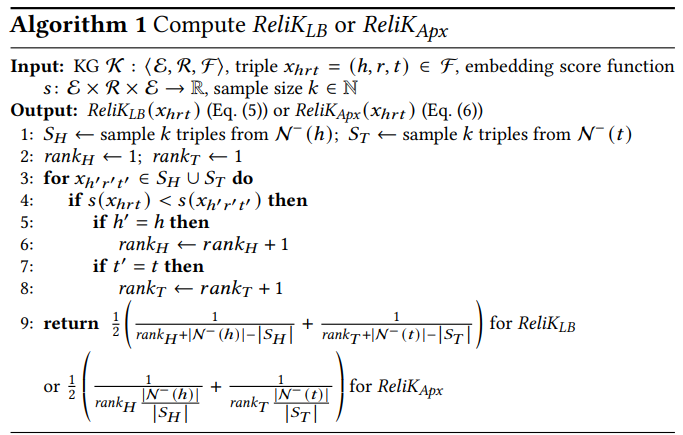

The ReliK function implemented here computes the approximations given by $ReliK_{LB}$ and $ReliK_{Apx}$ as seen in the image above.

To sample from the negative neighbourhoods of a triple's head and tail, I define an ordering of all possible triples with that head and tail respectively, based on the integer indexes assigned to the entities and relations (for example using the `entity_to_id`/ `relation_to_id` attribute of the pykeen `TriplesFactory` object of the trained embedding model, or assigning IDs manually). Then, I remove from that collection of indexes all those corresponding to positive triples. What remains is the negative neighbourhood of the head and tail respectively. Pytorch tensors and vectorization are used to speed up the computation.

For the head, I obtained the indexes as follows (for the tail it is analogous):

Let $E$ be the total number of unique entities and $R$ the total number of unique relations. Given a head $h$, and assuming that a triple can have the same entity for head and tail, there exist $R \cdot E$ triples with head $h$. Each entity and each relation is assigned an integer ID, and these IDs are ordered from 0 to E-1 for the entities, and from 0 to R-1 for the relations. We can define an ordering for all the triples, from $0$ to $R \cdot E - 1$, such that for every index $i$ of a triple $(h, r_i, t_i)$, the following holds:

$$
i = r_i \cdot E + t_i
$$

Where $r_i \in \{0,\cdots,R-1\}$ and $t_i \in \{0,\cdots,E-1\}$ are the relation and tail IDs of the triple with index $i$. To retrieve $r_i$ and $t_i$ from $i$, we can compute:

```
r_i = i // E
t_i = i % E 
```

Once the negative neighbourhoods of head and tail are computed, $k$ samples are drawn from both of them randomly, and the target triple's $rank_H$ (head rank) and $rank_T$ (tail rank) are calculated as the rank of the positive triple with respect to the two neighbourhoods. The function `approximate_relik` returns both $ReliK_{LB}$ and $ReliK_{Apx}$. 

In [39]:
# Load pickled PosixPath on Windows (I trained the model on Colab and the file path is incompatible with Windows)
posix_backup = pathlib.PosixPath
pathlib.PosixPath = pathlib.WindowsPath

#  Load the training triples
train_tf = TriplesFactory.from_path_binary('trained models/RotatE/training_triples')  # 'TransE', 'RotatE' or 'ComplEx'

# Compute number of entities and relations
E = len(train_tf.entity_id_to_label.keys())
R = len(train_tf.relation_id_to_label.keys())
N = R * E

# Number of samples
k = int(0.1 * N) # can be a percentage of the total number of triples

# Compute ReliK score
triple = [0, 120, 13647]

relik_lb, relik_apx = approximate_relik(triple, train_tf, model, k)
print(f'ReliK lower bound: {relik_lb}, ReliK approximation: {relik_apx}')

ReliK lower bound: 3.228930957567114e-07, ReliK approximation: 3.515894522872754e-05


### Combine ReliK + Embedding Scores

The goal of this project is to study how ReliK scores can be used to re-rank or filter candidate triples. 

The problem is: predicting the missing element of an unseen triple (head, relation or tail), given a knowledge graph embedding with associated score function. 

Initially, a triple from the test set is selected, and one of its elements is removed. Then, the trained embedding model is used to produce a ranking of potential candidates for the missing element. Each candidate triple corresponds to a score. Now we want to combine this score with the reliability algorithm.

#### Method 1

One approach is to compute the reliability score of the candidate triples, and then, for each of those triples, to calculate the convex combination of the embedding score and the ReliK score. Ideally, the best candidates should have a high rank and high ReliK score. However, if the ReliK score of a triple is low while their rank is high, the combined score can down-rank this triple, taking into account reliability. 

$$
\text{CombinedScore} = \lambda \cdot \text{ModelScore} + (1- \lambda) \cdot \text{ReliKScore}
$$

In [40]:
# Create a TriplesFactory object from the test triples, using the same ID mapping as for the entities and relations furing training
# Entities/ relations missing in the mapping but present in the test set are filtered out (the fraction is small)
test_tf = TriplesFactory.from_path(
    'fb15k-237/test.txt',
    entity_to_id=train_tf.entity_to_id,
    relation_to_id=train_tf.relation_to_id,
)

# Store the test triples with IDs in place of strings
test_triples = list(test_tf.mapped_triples)

print(test_triples[:5])

# Shuffle the test triples
random.seed = SEED
random.shuffle(test_triples)

print(test_triples[:5])

You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out


[tensor([   2,  131, 4267]), tensor([   4,  131, 4267]), tensor([  5, 126,   5]), tensor([   7,  131, 4267]), tensor([   9,  131, 4267])]
[tensor([ 5621,   129, 14004]), tensor([10724,   126, 10724]), tensor([8147,   96,  440]), tensor([4120,  180, 5460]), tensor([3280,   59, 2812])]


In [ ]:
# Open the train.txt file with entities
with open('fb15k-237/train.txt', 'r') as f:
    train_triples = [line.strip().split('\t') for line in f]

# Build a mid to name dictionary
mid2name = build_mid_name_dict("fb15k-237/FB15k_mid2name.txt")

# Get the types of the entities and build dictionaries with names, mids, and IDs to their types
head_types, tail_types = extract_types(train_triples)
head_types_with_name = {mid2name[mid]: head_types[mid] for mid in head_types.keys()}
tail_types_with_name = {mid2name[mid]: tail_types[mid] for mid in tail_types.keys()}
head_types_with_id = {train_tf.entity_to_id[mid]: head_types[mid] for mid in head_types.keys()}
tail_types_with_id = {train_tf.entity_to_id[mid]: tail_types[mid] for mid in tail_types.keys()}

# Save all the dictionaries
#pickle.dump(mid2name, open('data/mid2name.pkl', 'wb'))
#pickle.dump(head_types, open('data/head_types.pkl', 'wb'))
#pickle.dump(tail_types, open('data/tail_types.pkl', 'wb'))
#pickle.dump(head_types_with_name, open('data/head_types_with_name.pkl', 'wb'))
#pickle.dump(tail_types_with_name, open('data/tail_types_with_name.pkl', 'wb'))
#pickle.dump(head_types_with_id, open('data/TransE/head_types_with_id.pkl', 'wb'))
#pickle.dump(tail_types_with_id, open('data/TransE/tail_types_with_id.pkl', 'wb'))

In [6]:
# Read the dictionaries
with open('data/mid2name.pkl', 'rb') as f:
    mid2name = pickle.load(f)
with open('data/head_types.pkl', 'rb') as f:
    head_types = pickle.load(f)
with open('data/tail_types.pkl', 'rb') as f:
    tail_types = pickle.load(f)
with open('data/head_types_with_name.pkl', 'rb') as f:
    head_types_with_name = pickle.load(f)
with open('data/tail_types_with_name.pkl', 'rb') as f:
    tail_types_with_name = pickle.load(f)
with open('data/TransE/head_types_with_id.pkl', 'rb') as f:
    head_types_with_id = pickle.load(f)
with open('data/TransE/tail_types_with_id.pkl', 'rb') as f:
    tail_types_with_id = pickle.load(f)

In [37]:
# Reload functions
import importlib
import functions
importlib.reload(functions)
from functions import *

In [ ]:
# Parameters
num_candidates = 50 # number of candidates to consider
num_samples = 5000 # k in the ReliK algorithm
num_triples = 500 # can be len(test_triples) or less

# Initialize results dictionaries
predictions_results = dict()

# Iterate over test triples
for triple in tqdm(test_triples[:num_triples]):

    # Get the components
    head = int(triple[0])
    relation = int(triple[1])
    tail = int(triple[2])

    # Set tail to None for prediction
    tail = None

    # Compute embedding + ReliK scores
    prediction = compute_scores(model, train_tf, num_candidates, num_samples, tail_types, head=head, relation=relation, tail=tail, verbose=False)

    # Save results
    predictions_results[(head, relation)] = {'prediction': prediction, 'true_tail': int(triple[2])}

#file_path = 'results/TransE/'
#pickle.dump(predictions_results, open(file_path + 'predictions.pkl', 'wb'))

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [5:19:50<00:00, 38.38s/it]  


In [65]:
predictions_results = pickle.load(open('results/ComplEx/predictions.pkl', 'rb'))
#predictions_results

In [44]:
predictions_results[(1821,99)]['prediction'].columns

Index(['tail_id', 'score', 'tail_label', 'min_max_model', 'min_max_relik',
       'sigmoid_model', 'relik'],
      dtype='object')

In [66]:
# Number of triples
num_triples = 500

# Define a set of lambdas
lambdas = np.linspace(0, 1, 50)

# Store combined predictions
combined_predictions = {}

hits_at_1 = dict()
hits_at_3 = dict()
hits_at_5 = dict()
hits_at_10 = dict()

# Iterate through the lambdas
for lambda_ in lambdas:

    hit_at_1 = np.zeros(num_triples)
    hit_at_3 = np.zeros(num_triples)
    hit_at_5 = np.zeros(num_triples)
    hit_at_10 = np.zeros(num_triples)

    # Iterate through test triples
    for i, triple in enumerate(predictions_results.items()):

        #print(triple)
        # True tail
        predictions, true_tail = triple[1]['prediction'], triple[1]['true_tail']

        # Combine model scores with a convex combination
        # model_norm = 'min_max_model' (min-max normalization), 'sigmoid_model' (sigmoid normalization), 'score' (normal model score)
        # relik = 'relik' (normal relik score), 'min_max_relik' (min-max relik normalization)
        result = evaluate_combined_scores(predictions, true_tail, lambda_, filter=False, model_norm='min_max_model', relik='min_max_relik')

        # Add the hit at k 0/1
        hit_at_1[i] = result['hit_at_1']
        hit_at_3[i] = result['hit_at_3']
        hit_at_5[i] = result['hit_at_5']
        hit_at_10[i] = result['hit_at_10']

        # Store the predictions
        combined_predictions[(triple[0], lambda_)] = result['predictions']

    hits_at_1[float(lambda_)] = float(np.mean(hit_at_1))
    hits_at_3[float(lambda_)] = float(np.mean(hit_at_3))
    hits_at_5[float(lambda_)] = float(np.mean(hit_at_5))
    hits_at_10[float(lambda_)] = float(np.mean(hit_at_10))

# Print hits@k for 1,3,5,10
# print(f'Hits@1: {hits_at_1}')
# print(f'Hits@3: {hits_at_3}')
# print(f'Hits@3: {hits_at_5}')
# print(f'Hits@10: {hits_at_10}')

In [ ]:
#file_path = 'results/TransE/'
#pickle.dump(combined_predictions, open(file_path + 'combined_predictions.pkl', 'wb'))

In [67]:
hits_at_k_df = pd.DataFrame(hits_at_1.items(), columns=['Lambda', 'Hits@1'])
hits_at_k_df['Hits@3'] = hits_at_3.values()
hits_at_k_df['Hits@5'] = hits_at_5.values()
hits_at_k_df['Hits@10'] = hits_at_10.values()
hits_at_k_df.head(10)

,Lambda,Hits@1,Hits@3,Hits@5,Hits@10
0,0.000000,0.062,0.112,0.150,0.234
1,0.020408,0.062,0.114,0.150,0.234
2,0.040816,0.062,0.114,0.150,0.234
3,0.061224,0.062,0.114,0.150,0.234
4,0.081633,0.062,0.114,0.152,0.234
5,0.102041,0.062,0.114,0.152,0.234
6,0.122449,0.062,0.114,0.152,0.234
7,0.142857,0.062,0.114,0.152,0.234
8,0.163265,0.062,0.114,0.152,0.234
9,0.183673,0.062,0.114,0.152,0.234


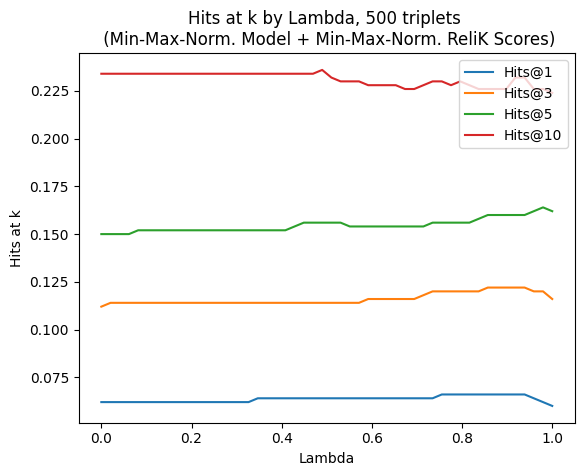

In [68]:
# Plot hits @ k by Lambda
sorted_lambdas_1 = hits_at_1.keys()
sorted_hits_at_1 = [hits_at_1[lambda_] for lambda_ in sorted_lambdas_1]

sorted_lambdas_3 = hits_at_3.keys()
sorted_hits_at_3 = [hits_at_3[lambda_] for lambda_ in sorted_lambdas_3]

sorted_lambdas_5 = hits_at_5.keys()
sorted_hits_at_5 = [hits_at_5[lambda_] for lambda_ in sorted_lambdas_5]

sorted_lambdas_10 = hits_at_10.keys()
sorted_hits_at_10 = [hits_at_10[lambda_] for lambda_ in sorted_lambdas_10]

plt.plot(sorted_lambdas_1, sorted_hits_at_1, label='Hits@1')
plt.plot(sorted_lambdas_3, sorted_hits_at_3, label='Hits@3')
plt.plot(sorted_lambdas_5, sorted_hits_at_5, label='Hits@5')
plt.plot(sorted_lambdas_10, sorted_hits_at_10, label='Hits@10')
plt.xlabel('Lambda')
plt.ylabel('Hits at k')
plt.title('Hits at k by Lambda, 500 triplets \n (Min-Max-Norm. Model + Min-Max-Norm. ReliK Scores)')
plt.legend()
plt.show()

#### Method 2

A second strategy for combining embedding scores with ReliK scores could be the following: instead of computing the ReliK scores of the candidate triples, for which we do not know whether they are positive or negative, we can look at the *positive* neighbourhoods of the candidate triples, and see how accurately the average local ReliK score in that subgraph is, then combine this score with the candidate's embedding score. 

The reasoning is that, if a neighbourhood has consistently high ReliK scores, then nearby candidate triples are more likely to have trustworthy embedding scores.

In [ ]:
# Parameters
num_candidates = 20 # number of candidates to consider
num_samples = 1000 # k in the ReliK algorithm
num_triples = 100 # can be len(test_triples) or less
num_nb = 30 # try 20

# Initialize results dictionaries
predictions_results2 = dict()

# Use the same triples as in the other experiment, for comparison
predictions_results = pickle.load(open('results/TransE/predictions.pkl', 'rb'))
test_triples = list(predictions_results.keys()) # with missing tail
true_tails = [predictions_results[triple]['true_tail'] for triple in test_triples]

# Load cached local relik scores for faster computation
cache = pickle.load(open('data/RotatE/local_relik_scores_tails.pkl', 'rb'))

# Iterate over test triples
for i, triple in tqdm(enumerate(test_triples[:num_triples])):

    # Get the components
    head = int(triple[0])
    relation = int(triple[1])

    # Set tail to None for prediction
    tail = None

    # Compute embedding + ReliK scores
    prediction = compute_scores2(model, train_tf, num_candidates, num_nb, num_samples, tail_types, cache, head=head, relation=relation, tail=tail, verbose=False)

    # Save results
    predictions_results2[(head, relation)] = {'prediction': prediction, 'true_tail': true_tails[i]}

#file_path = 'results/TransE/'
#pickle.dump(predictions_results2, open(file_path + 'predictions2.pkl', 'wb')) # save the predictions file
#pickle.dump(cache, open('data/TransE/local_relik_scores_tails.pkl', 'wb')) # update the cache file

6it [14:55, 169.80s/it]C:\Users\galax\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\galax\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
8it [17:41, 127.55s/it]C:\Users\galax\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\galax\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
10it [21:29, 121.74s/it]C:\Users\galax\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\User

In [69]:
cache = pickle.load(open('data/ComplEx/local_relik_scores_tails.pkl', 'rb'))
predictions_results2 = pickle.load(open('results/ComplEx/predictions2.pkl', 'rb'))
len(cache)

2174

In [70]:
# Number of triples
num_triples = 100

# Define a set of lambdas
lambdas = np.linspace(0, 1, 50)

# Store combined predictions
combined_predictions2 = {}

hits_at_1 = dict()
hits_at_3 = dict()
hits_at_5 = dict()
hits_at_10 = dict()

# Iterate through the lambdas
for lambda_ in lambdas:

    hit_at_1 = np.zeros(num_triples)
    hit_at_3 = np.zeros(num_triples)
    hit_at_5 = np.zeros(num_triples)
    hit_at_10 = np.zeros(num_triples)

    # Iterate through test triples
    for i, triple in enumerate(predictions_results2.items()):

        #print(triple)
        # True tail
        predictions, true_tail = triple[1]['prediction'], triple[1]['true_tail']

        # Combine model scores with a convex combination
        result = evaluate_combined_scores(predictions, true_tail, lambda_, threshold=1e-5, filter=False, model_norm='min_max_model', relik='min_max_relik')

        # Add the hit at k 0/1
        hit_at_1[i] = result['hit_at_1']
        hit_at_3[i] = result['hit_at_3']
        hit_at_5[i] = result['hit_at_5']
        hit_at_10[i] = result['hit_at_10']

        # Store the predictions
        combined_predictions2[(triple[0], lambda_)] = result['predictions']

    hits_at_1[float(lambda_)] = float(np.mean(hit_at_1))
    hits_at_3[float(lambda_)] = float(np.mean(hit_at_3))
    hits_at_5[float(lambda_)] = float(np.mean(hit_at_5))
    hits_at_10[float(lambda_)] = float(np.mean(hit_at_10))

# Print hits@k for 1,3,5,10
# print(f'Hits@1: {hits_at_1}')
# print(f'Hits@3: {hits_at_3}')
# print(f'Hits@3: {hits_at_5}')
# print(f'Hits@10: {hits_at_10}')

In [ ]:
#file_path = 'results/TransE/'
#pickle.dump(combined_predictions2, open(file_path + 'combined_predictions2.pkl', 'wb'))

In [71]:
hits_at_k_df = pd.DataFrame(hits_at_1.items(), columns=['Lambda', 'Hits@1'])
hits_at_k_df['Hits@3'] = hits_at_3.values()
hits_at_k_df['Hits@5'] = hits_at_5.values()
hits_at_k_df['Hits@10'] = hits_at_10.values()
hits_at_k_df.head(10)

,Lambda,Hits@1,Hits@3,Hits@5,Hits@10
0,0.000000,0.11,0.19,0.22,0.32
1,0.020408,0.12,0.19,0.23,0.32
2,0.040816,0.12,0.19,0.23,0.31
3,0.061224,0.12,0.19,0.23,0.31
4,0.081633,0.12,0.19,0.23,0.31
5,0.102041,0.12,0.19,0.23,0.30
6,0.122449,0.12,0.19,0.23,0.30
7,0.142857,0.12,0.19,0.23,0.30
8,0.163265,0.12,0.19,0.23,0.30
9,0.183673,0.12,0.19,0.23,0.30


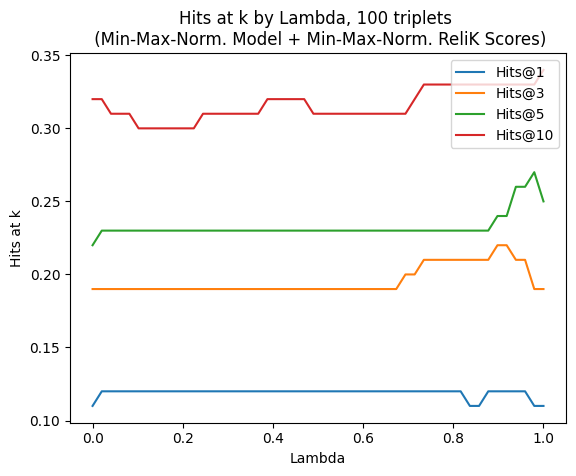

In [72]:
# Plot hits @ k by Lambda
sorted_lambdas_1 = hits_at_1.keys()
sorted_hits_at_1 = [hits_at_1[lambda_] for lambda_ in sorted_lambdas_1]

sorted_lambdas_3 = hits_at_3.keys()
sorted_hits_at_3 = [hits_at_3[lambda_] for lambda_ in sorted_lambdas_3]

sorted_lambdas_5 = hits_at_5.keys()
sorted_hits_at_5 = [hits_at_5[lambda_] for lambda_ in sorted_lambdas_5]

sorted_lambdas_10 = hits_at_10.keys()
sorted_hits_at_10 = [hits_at_10[lambda_] for lambda_ in sorted_lambdas_10]

plt.plot(sorted_lambdas_1, sorted_hits_at_1, label='Hits@1')
plt.plot(sorted_lambdas_3, sorted_hits_at_3, label='Hits@3')
plt.plot(sorted_lambdas_5, sorted_hits_at_5, label='Hits@5')
plt.plot(sorted_lambdas_10, sorted_hits_at_10, label='Hits@10')
plt.xlabel('Lambda')
plt.ylabel('Hits at k')
plt.title('Hits at k by Lambda, 100 triplets \n (Min-Max-Norm. Model + Min-Max-Norm. ReliK Scores)')
plt.legend()
plt.show()

In [19]:
print(hits_at_1)
print(hits_at_3)
print(hits_at_5)
print(hits_at_10)

{0.0: 0.12, 0.02040816326530612: 0.13, 0.04081632653061224: 0.13, 0.061224489795918366: 0.13, 0.08163265306122448: 0.12, 0.1020408163265306: 0.12, 0.12244897959183673: 0.12, 0.14285714285714285: 0.12, 0.16326530612244897: 0.12, 0.18367346938775508: 0.12, 0.2040816326530612: 0.12, 0.22448979591836732: 0.12, 0.24489795918367346: 0.12, 0.26530612244897955: 0.12, 0.2857142857142857: 0.12, 0.3061224489795918: 0.12, 0.32653061224489793: 0.12, 0.3469387755102041: 0.12, 0.36734693877551017: 0.12, 0.3877551020408163: 0.12, 0.4081632653061224: 0.12, 0.42857142857142855: 0.12, 0.44897959183673464: 0.12, 0.4693877551020408: 0.12, 0.4897959183673469: 0.12, 0.5102040816326531: 0.12, 0.5306122448979591: 0.12, 0.5510204081632653: 0.12, 0.5714285714285714: 0.12, 0.5918367346938775: 0.12, 0.6122448979591836: 0.12, 0.6326530612244897: 0.12, 0.6530612244897959: 0.12, 0.673469387755102: 0.12, 0.6938775510204082: 0.12, 0.7142857142857142: 0.12, 0.7346938775510203: 0.12, 0.7551020408163265: 0.12, 0.775510204